<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_4_SLR_Influence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Influence, Leverage, and Cook's Distance

Author: Brad Sheese

---


## What This Notebook Is About

In Notebook 17_1_3 we learned to check the LINE assumptions by looking at the *overall shape* of the residuals — the band, the curve, the funnel, the Q-Q tails. That's the right tool for checking whether a model is broken *as a whole*.

But sometimes the model is mostly fine, and a **single row of your dataset** is doing all the damage. One bad house, one mis-typed number, one fundamentally different observation hiding in a dataset of 2,930 — and your slope, your $R^2$, and your p-value all go haywire. The summary table won't tell you. The LINE diagnostics might, but they'll show it as a vague "heavy tail" in the Q-Q plot, not as a specific accusation.

This notebook is about the specific accusation. We'll learn to answer the question:

> **Which specific rows in my dataset are actually moving my regression line — and by how much?**

There are three concepts we need to pull apart carefully, because people use them interchangeably and they are *not* the same thing:

| Term | Meaning | Which axis is weird |
|---|---|---|
| **Leverage** | The point has an unusual $x$ value | $x$ |
| **Outlier** | The point has an unusual $y$ value (big residual) | $y$ |
| **Influence** | Removing this point would meaningfully move the line | *both* |

A point can be an outlier without being influential. A point can have high leverage without being influential. The points that really hurt us are the ones with **high leverage *and* a large residual** — and there's a single, beautiful number that catches exactly those: **Cook's Distance**.

We'll use a dataset you've already seen — **Ames Housing** from 17_0_5 — and we'll poison it with one fake row to give ourselves a villain to hunt.

## Setup

We'll reload the Ames Housing dataset exactly as we did in 17_0_5 — 2,930 homes in Ames, Iowa, with `area` (above-ground living area in square feet) predicting `price` (sale price in thousands of dollars).

Then we'll **inject one fake row**: a single 10,000-square-foot mansion that allegedly sold for \$500. This is pure nonsense data — no 10,000-square-foot house has ever sold for \$500 — but it's exactly the kind of thing that can sneak into a real dataset from a data-entry typo, a unit-conversion error, or a row that was supposed to be deleted and wasn't.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import io
import urllib.request

import statsmodels.api as sm

sns.set_style('whitegrid')
rng = np.random.default_rng(seed=42)

# Ames Housing from OpenIntro (same loader as 17_0_5).
url = 'https://www.openintro.org/data/csv/ames.csv'
req = urllib.request.Request(
    url,
    headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36',
             'Accept': 'text/csv,*/*'},
)
with urllib.request.urlopen(req) as resp:
    ames = pd.read_csv(io.BytesIO(resp.read()))

ames = ames[['area', 'price']].copy()
ames['price'] = ames['price'] / 1000.0   # price in $ thousands, same as 17_0_5

# Inject ONE poisoned row: 10,000 sq ft house that 'sold' for $500 (= 0.5 thousand).
poison_row = pd.DataFrame({'area': [10_000], 'price': [0.5]})
ames = pd.concat([ames, poison_row], ignore_index=True)

print(f'Total rows after poisoning: {len(ames)}')
print(f'Poisoned row is at index:   {len(ames) - 1}')

Total rows after poisoning: 2931
Poisoned row is at index:   2930


Now we fit the same simple linear regression on the poisoned data.

In [2]:
X = sm.add_constant(ames['area'])
y = ames['price']

model_bad = sm.OLS(y, X).fit()

print(f'Slope     : {model_bad.params["area"]:.4f} $K per sq ft')
print(f'Intercept : {model_bad.params["const"]:.2f} $K')
print(f'R^2       : {model_bad.rsquared:.4f}')

Slope     : 0.1000 $K per sq ft
Intercept : 30.48 $K
R^2       : 0.4383


Compare that $R^2$ to what we got in Notebook 17_0_5 on the clean dataset: **0.50**. On the poisoned dataset, it's dropped to **0.44** — a sizable hit from *one row out of 2,931*. The slope has changed too (0.100 instead of roughly 0.112 from before). Our regression has been mugged.

But here's the key question: if you hadn't been told there was a poisoned row, **would you have noticed?**

---

## Section 1: The Needle in the Haystack

When you have 10 data points, spotting an outlier is easy. You just look at the scatterplot. With 2,931 points on a standard matplotlib canvas, the eye is much less helpful.

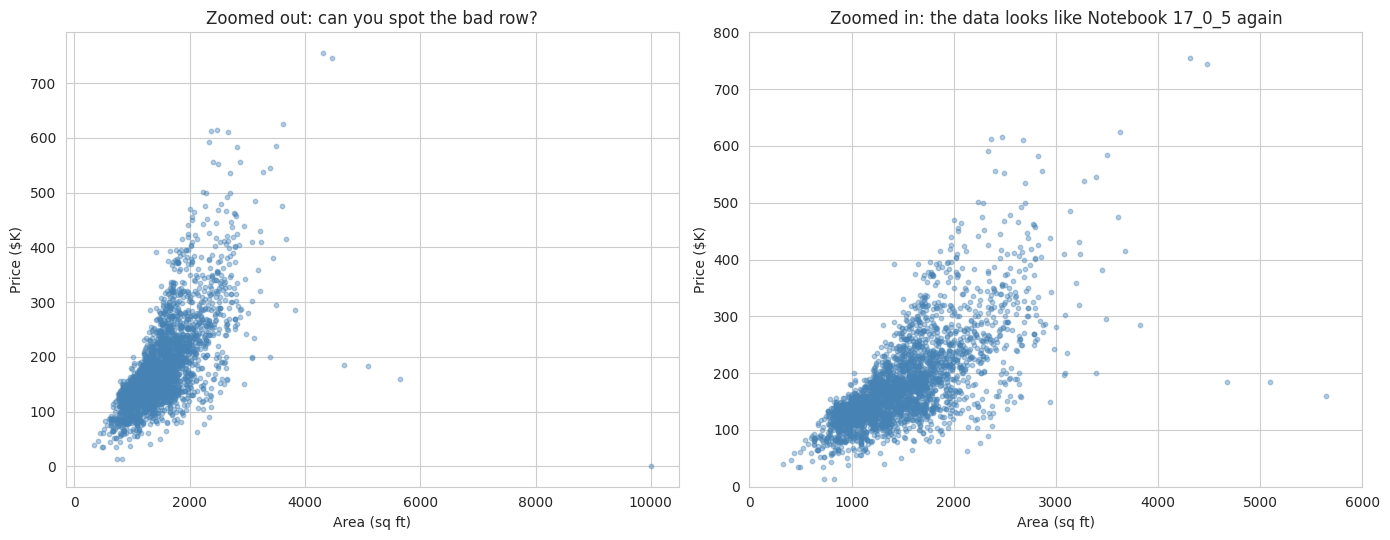

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: zoomed out — the poisoned point is visible as a dot in the far corner.
axes[0].scatter(ames['area'], ames['price'], s=10, alpha=0.4, color='steelblue')
axes[0].set_xlabel('Area (sq ft)')
axes[0].set_ylabel('Price ($K)')
axes[0].set_title('Zoomed out: can you spot the bad row?')

# Right: zoomed into the normal data range — the poisoned point is off-screen
# and the remaining 2,930 houses look perfectly fine.
axes[1].scatter(ames['area'], ames['price'], s=10, alpha=0.4, color='steelblue')
axes[1].set_xlim(0, 6000)
axes[1].set_ylim(0, 800)
axes[1].set_xlabel('Area (sq ft)')
axes[1].set_ylabel('Price ($K)')
axes[1].set_title('Zoomed in: the data looks like Notebook 17_0_5 again')

plt.tight_layout()
plt.show()

In the zoomed-out view on the left, there's a single sad-looking dot at the bottom-right corner. Easy to spot here because we already know to look for it. In a real-world data pipeline — where you might have dozens of features, millions of rows, and no reason to think any one row is suspicious — you'd never zoom out far enough to see it.

The zoomed-in view on the right shows what a busy analyst actually sees: a reasonable-looking housing scatterplot, blissfully unaware that one row off-screen is doing all the damage.

> **We need algorithms that look at every row and flag the damaging ones, without us having to guess where to look.** That is exactly what influence diagnostics are for.

---

## Section 2: Leverage ≠ Outlier ≠ Influence

Before we go hunting in Ames, let's lock down the vocabulary with a tiny pedagogical dataset where we can see the geometry. Four panels, same clean baseline data in each, but with a different contaminating point in the last three.

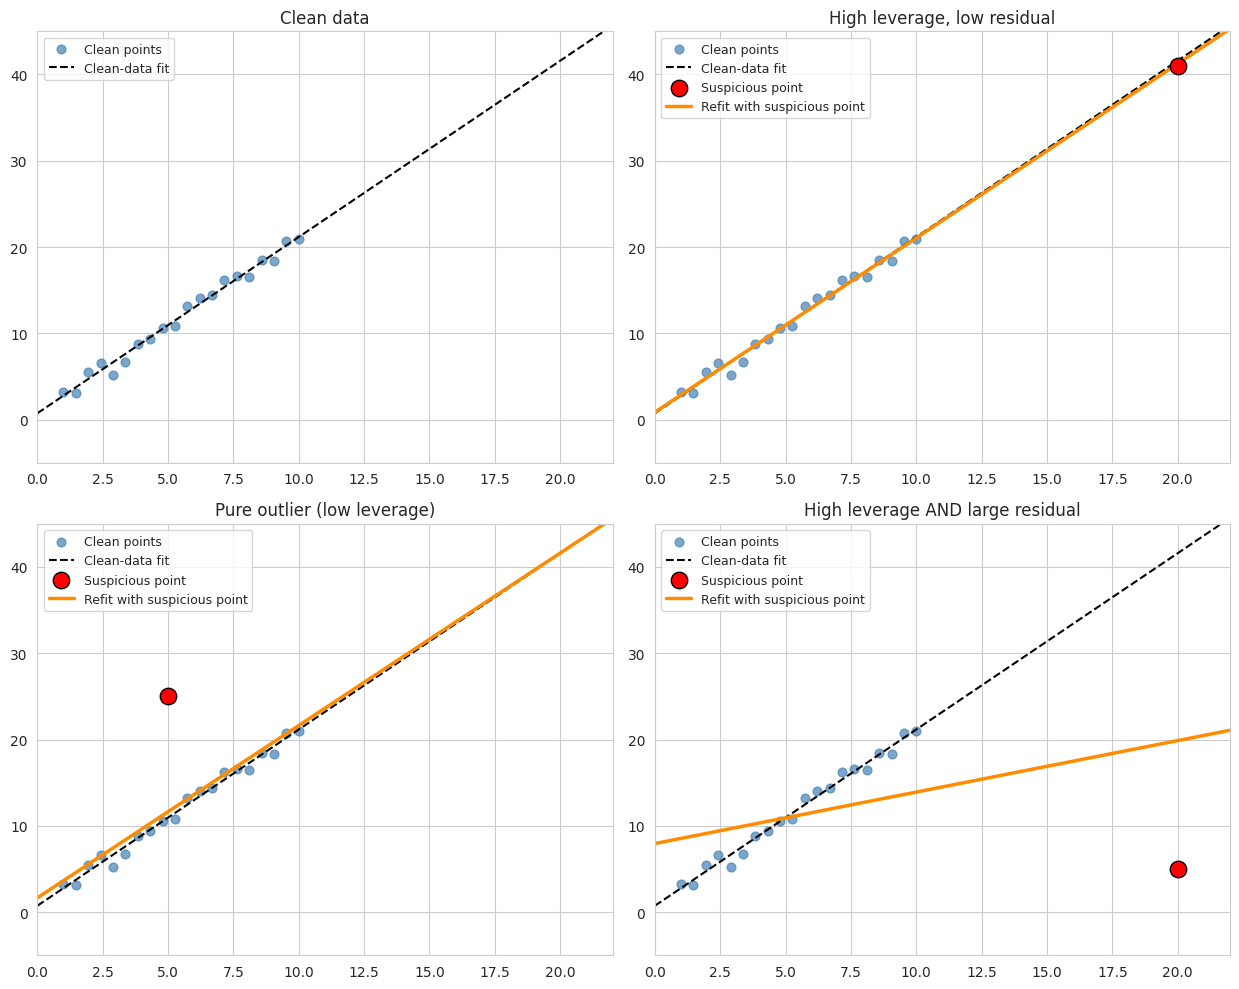

In [4]:
# 20 points that fall on a clean line y = 2x + 1 with a bit of noise.
x_toy = np.linspace(1, 10, 20)
y_toy = 2 * x_toy + 1 + rng.normal(0, 0.8, size=20)

def fit_line(x_data, y_data):
    X_data = sm.add_constant(x_data)
    return sm.OLS(y_data, X_data).fit()

# Four scenarios:
scenarios = [
    {'title': 'Clean data',                      'extra': None},
    {'title': 'High leverage, low residual',     'extra': (20, 41)},   # x=20 (way out), y agrees with line
    {'title': 'Pure outlier (low leverage)',     'extra': (5, 25)},    # x in the middle, y way above line
    {'title': 'High leverage AND large residual','extra': (20, 5)},    # x=20 and y way below line
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 10))
clean_model = fit_line(x_toy, y_toy)
x_line = np.linspace(0, 22, 100)

for ax, scen in zip(axes.flatten(), scenarios):
    ax.scatter(x_toy, y_toy, s=40, color='steelblue', alpha=0.7, label='Clean points')

    # Always show the clean-data line in black as a reference.
    ax.plot(x_line, clean_model.predict(sm.add_constant(x_line)),
            color='black', linestyle='--', linewidth=1.5, label='Clean-data fit')

    if scen['extra'] is not None:
        xe, ye = scen['extra']
        ax.scatter([xe], [ye], s=140, color='red', edgecolor='black',
                   zorder=5, label='Suspicious point')
        # Refit with the extra point and show the new line in orange.
        x_all = np.append(x_toy, xe)
        y_all = np.append(y_toy, ye)
        m = fit_line(x_all, y_all)
        ax.plot(x_line, m.predict(sm.add_constant(x_line)),
                color='darkorange', linewidth=2.5, label='Refit with suspicious point')

    ax.set_xlim(0, 22)
    ax.set_ylim(-5, 45)
    ax.set_title(scen['title'])
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Look at what each panel does to the orange regression line relative to the black reference line.

- **Top-left (clean data).** No contamination; the orange line *is* the black line. Baseline.
- **Top-right (high leverage, small residual).** The red point is far to the right (way outside the normal $x$ range — that's high leverage), but its $y$ value sits right on the extrapolated line. It agrees with what the other data was saying. The orange and black lines lie on top of each other. **High leverage alone is not a problem.** The point is weird in $x$, but it's not arguing with anyone.
- **Bottom-left (pure outlier, low leverage).** The red point has a normal $x$ value (sitting right in the middle of the cloud), but its $y$ value is wildly too high — a large residual. Yet the orange line barely moves off the black line. **A big residual alone is not very damaging** when it sits near the average $x$, because the line pivots around the middle of the data and a point in the middle can't swing the slope much.
- **Bottom-right (high leverage AND large residual).** Same extreme $x$ as panel two, but now the $y$ value is *way* below the extrapolated line. The orange line tilts sharply downward, completely different from the black reference. **This is the dangerous combination.** A point that is both weird in $x$ *and* disagrees with the trend drags the line toward itself with enormous force.

> **Moral: influence = leverage × disagreement.** A point only moves the regression line if it's both an unusual $x$ *and* a large residual. Cook's Distance is the single number that captures this exact product.

Our poisoned Ames row — 10,000 sq ft, \$500 — is textbook bottom-right. It has the most extreme $x$ in the dataset (enormous leverage) and the most extreme residual (enormous disagreement).

---

## Section 3: Hunting in Ames with `.get_influence()`

Statsmodels gives us an influence-diagnostics object off any fitted model: `model.get_influence()`. It computes every row-by-row diagnostic you could want, in one call.

In [5]:
influence = model_bad.get_influence()

leverages     = influence.hat_matrix_diag              # h_ii — the leverage of each row
stud_resids   = influence.resid_studentized_external   # 'outlierness' in y
cooks_d, _    = influence.cooks_distance               # combines both

poison_idx = len(ames) - 1  # we injected it as the last row

print(f'Poisoned row (index {poison_idx}):')
print(f'  Leverage           : {leverages[poison_idx]:.4f}')
print(f'  Studentized resid  : {stud_resids[poison_idx]:.2f}')
print(f'  Cook\'s Distance   : {cooks_d[poison_idx]:.3f}')
print()
print(f'For comparison — max values across all OTHER rows:')
others = np.arange(len(ames)) != poison_idx
print(f'  Max leverage elsewhere          : {leverages[others].max():.4f}')
print(f'  Max |studentized resid| elsewhere: {np.abs(stud_resids[others]).max():.2f}')
print(f'  Max Cook\'s Distance elsewhere  : {cooks_d[others].max():.4f}')

Poisoned row (index 2930):
  Leverage           : 0.0883
  Studentized resid  : -19.08
  Cook's Distance   : 15.695

For comparison — max values across all OTHER rows:
  Max leverage elsewhere          : 0.0212
  Max |studentized resid| elsewhere: 7.40
  Max Cook's Distance elsewhere  : 0.5826


The numbers tell the story before we even plot anything:

- The poisoned row's **leverage is roughly 4× bigger** than the most extreme leverage elsewhere in the dataset.
- Its **studentized residual is about 19 standard deviations** in magnitude. (A studentized residual over ~3 is already considered unusual. Nineteen is science fiction.)
- Its **Cook's Distance is enormous** — roughly 27× larger than the largest legitimate row, and over ten thousand times the rule-of-thumb threshold of $4/n$.

Now let's see it visually. Stem plots make spikes impossible to miss.

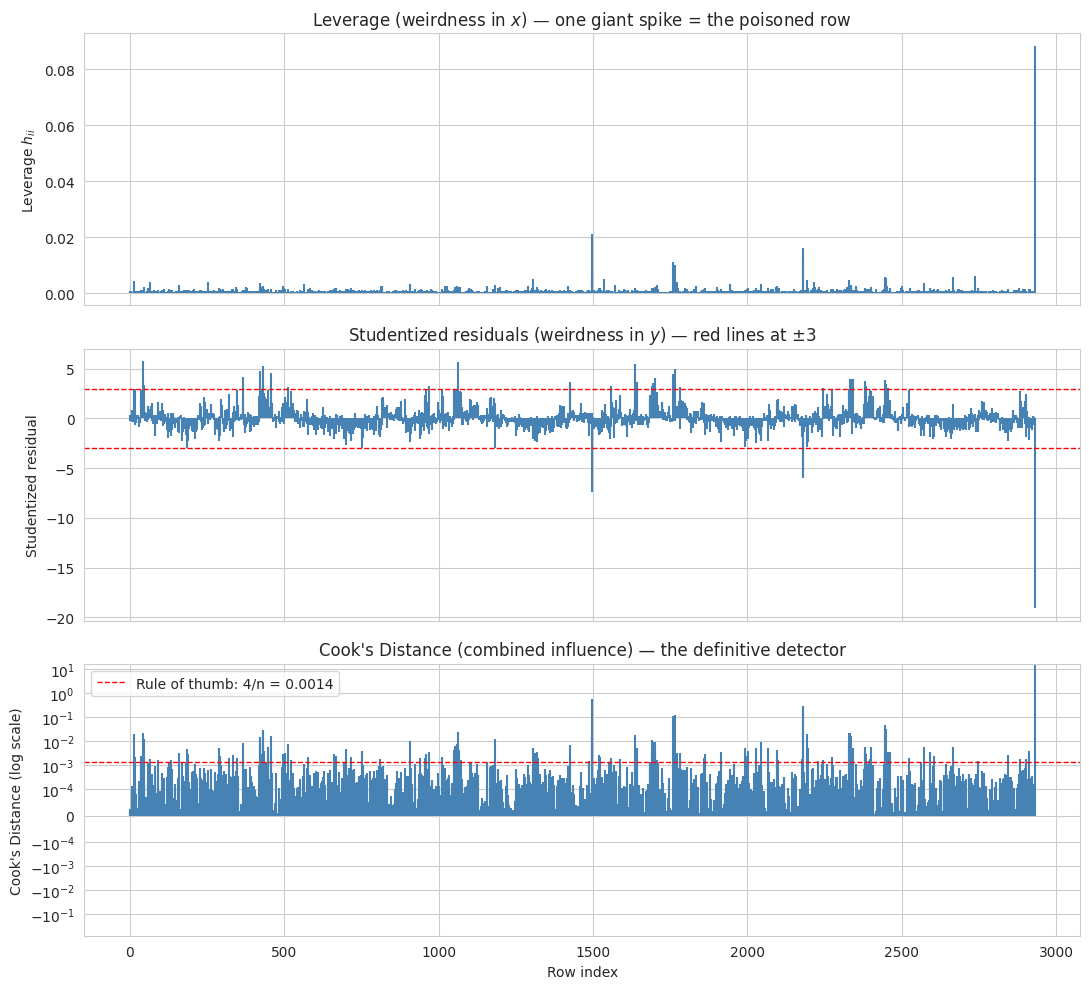

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# Row 1: leverage (h_ii)
markerline, stemlines, baseline = axes[0].stem(leverages, markerfmt=' ', basefmt=' ',
                                               linefmt='steelblue')
axes[0].set_ylabel('Leverage $h_{ii}$')
axes[0].set_title('Leverage (weirdness in $x$) — one giant spike = the poisoned row')

# Row 2: studentized residuals
markerline, stemlines, baseline = axes[1].stem(stud_resids, markerfmt=' ', basefmt=' ',
                                               linefmt='steelblue')
axes[1].axhline(3, color='red', linestyle='--', linewidth=1)
axes[1].axhline(-3, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Studentized residual')
axes[1].set_title('Studentized residuals (weirdness in $y$) — red lines at $\\pm 3$')

# Row 3: Cook's Distance — use log scale so smaller spikes are visible too.
markerline, stemlines, baseline = axes[2].stem(cooks_d, markerfmt=' ', basefmt=' ',
                                               linefmt='steelblue')
axes[2].axhline(4 / len(ames), color='red', linestyle='--', linewidth=1,
                label=f'Rule of thumb: 4/n = {4/len(ames):.4f}')
axes[2].set_yscale('symlog', linthresh=1e-4)
axes[2].set_ylabel("Cook's Distance (log scale)")
axes[2].set_xlabel('Row index')
axes[2].set_title("Cook's Distance (combined influence) — the definitive detector")
axes[2].legend()

plt.tight_layout()
plt.show()

All three panels point to the same row, screaming. The poisoned row is the rightmost bar in every plot (because we injected it last, at the highest index) and it dwarfs everything else.

### Cook's Distance in one sentence

> **Cook's Distance for row $i$ measures how much every prediction in the dataset would change if we deleted row $i$ and refit the model.**

That's why it's the standard influence statistic: it directly answers the question *"would removing this row matter?"*. The common rule-of-thumb threshold is $D_i > 4/n$, which we've drawn as the red dashed line on the third panel. In our dataset, one row is orders of magnitude past that threshold, and every other row is well below it.

If Cook's Distance is the only one you remember, you've got 90% of what you need. Leverage and studentized residuals are useful supporting evidence, but Cook's bundles them together in the most practical way.

### Finding the suspect programmatically

In a real investigation we wouldn't know which row is the poisoned one. We'd find it by ranking rows by Cook's Distance.

In [7]:
# Attach Cook's D to the dataframe and look at the top offenders.
diagnostics = ames.copy()
diagnostics['cooks_d'] = cooks_d
diagnostics['leverage'] = leverages
diagnostics['stud_resid'] = stud_resids

diagnostics.sort_values('cooks_d', ascending=False).head(5)

,area,price,cooks_d,leverage,stud_resid
2930,10000,0.50,15.694687,0.088322,-19.083637
1498,5642,160.00,0.582641,0.021219,-7.398459
2180,5095,183.85,0.293016,0.016066,-6.026892
2181,4676,184.75,0.176808,0.012612,-5.285792
1767,4316,755.00,0.121721,0.009986,4.932344


The top row of that table — 10,000 sq ft for \$0.5K — is the poisoned one we injected. **In a production pipeline this is the moment you page a human.** A 10,000 sq ft house is physically plausible (big mansions exist); a \$500 sale price is not. A quick search of the data source would reveal it's an error and you'd have legitimate grounds to exclude it.

Notice the gap between row 1 and rows 2–5 of that table: our poisoned villain's Cook's Distance is roughly 27× any legitimate data point. Real-world influence problems don't always look this clean, but the top-of-the-list ranking is still the first place you should look.

---

## Section 4: The Drop Test

We've identified the bad row. What happens if we drop it and refit?

In [8]:
ames_clean = ames.drop(index=poison_idx).reset_index(drop=True)

X_clean = sm.add_constant(ames_clean['area'])
y_clean = ames_clean['price']
model_clean = sm.OLS(y_clean, X_clean).fit()

comparison = pd.DataFrame({
    'With poisoned row':    [model_bad.params['area'],   model_bad.params['const'],   model_bad.rsquared],
    'Without poisoned row': [model_clean.params['area'], model_clean.params['const'], model_clean.rsquared],
}, index=['Slope (per sq ft)', 'Intercept ($K)', 'R^2'])

comparison.round(4)

,With poisoned row,Without poisoned row
Slope (per sq ft),0.1000,0.1117
Intercept ($K),30.4800,13.2896
R^2,0.4383,0.4995


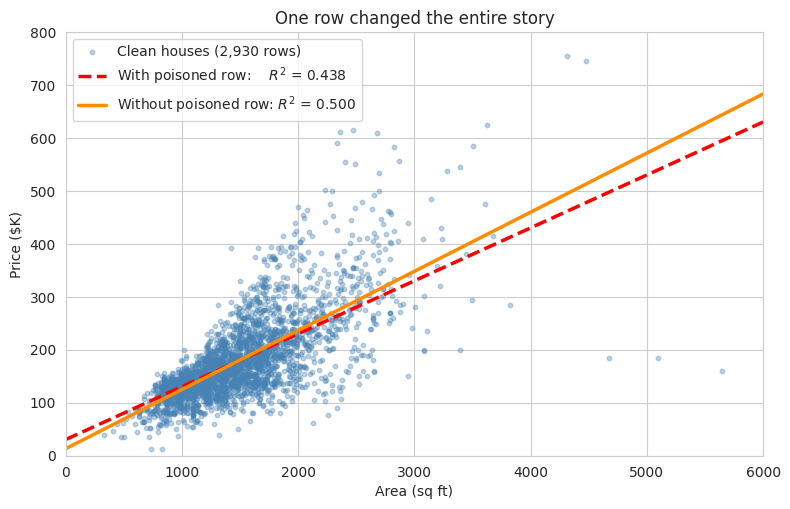

In [9]:
# Show both fitted lines on top of the clean data (inside the normal range).
x_grid = np.linspace(0, 6000, 200)
y_bad   = model_bad.predict(sm.add_constant(x_grid))
y_clean_line = model_clean.predict(sm.add_constant(x_grid))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(ames_clean['area'], ames_clean['price'], s=10, alpha=0.35, color='steelblue',
           label='Clean houses (2,930 rows)')
ax.plot(x_grid, y_bad, color='red', linewidth=2.5, linestyle='--',
        label=f'With poisoned row:    $R^2$ = {model_bad.rsquared:.3f}')
ax.plot(x_grid, y_clean_line, color='darkorange', linewidth=2.5,
        label=f'Without poisoned row: $R^2$ = {model_clean.rsquared:.3f}')
ax.set_xlim(0, 6000)
ax.set_ylim(0, 800)
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Price ($K)')
ax.set_title('One row changed the entire story')
ax.legend()
plt.show()

One row. One single row out of 2,931. Removing it sent the $R^2$ back up to 0.50 (which is exactly what we got on the clean data in Notebook 17_0_5), restored the slope, and rotated the line back to where it belongs.

That's influence. That's why it matters.

---

## Section 5: The Ethics of Dropping Data

We have to talk about this carefully, because the Cook's Distance tool we just learned can be **catastrophically misused** in industry, in science, and in student projects. The temptation is enormous: you fit a model, the $R^2$ is disappointing, you run `get_influence()`, you identify "the outliers", you drop them, and suddenly the numbers look great. You ship the model. You publish the paper.

**Do not do this.**

Here is the rule that separates legitimate data cleaning from statistical fraud:

> **A high Cook's Distance is a reason to *investigate*, never a reason to *delete*.**

You are allowed to remove a row if, *after investigation*, you can articulate a concrete substantive reason it doesn't belong:

- **Data entry error.** Our poisoned \$500 mansion. Someone typed `500` when they meant `500,000`. Excludable.
- **Wrong unit.** A temperature logged in Fahrenheit in a Celsius column. Excludable (or convertible).
- **Instrument failure.** A sensor stuck at zero during a 10-minute stretch of a longer run. Excludable.
- **Different population.** You're modeling single-family home prices and one row is actually a commercial warehouse that slipped through. Excludable (but document it).
- **Test observation never meant for the training set.** A known dummy row, a calibration point. Excludable.

You are **not** allowed to remove a row for any of these reasons:

- **"It was hurting my $R^2$."** That's what influence *means*. Deleting every point that hurts your fit gives you a model that describes a fantasy version of your data.
- **"It was flagged by Cook's Distance."** Cook's tells you which rows *could* be problematic. It does not tell you that any of them *are* problematic.
- **"The instructor / client / referee wanted a higher $R^2$."** No.

Here's the one-line version:

> **Cook's Distance is a detective, not an executioner.** It points at a suspect. You still have to do the investigating.

### What to do with genuinely influential points you can't legitimately drop

Sometimes you're stuck with a real data point that happens to be exerting a lot of leverage — not an error, just genuinely unusual. You have three professional options:

1. **Report results both with and without the influential point(s).** Transparent, honest, the gold standard for papers.
2. **Use robust regression.** Methods like Huber regression or RANSAC explicitly down-weight points with large residuals. `sklearn.linear_model.HuberRegressor` is a one-line swap.
3. **Model what's actually going on.** If a handful of points are genuinely different (e.g., mansions behave differently from regular homes), maybe your model is wrong — maybe you need separate models, or a nonlinear fit, or an extra feature that distinguishes the subgroups.

---

## Putting It All Together

A clean mental picture to carry away from this notebook:

| Diagnostic | What it measures | Rule-of-thumb flag |
|---|---|---|
| **Leverage** $h_{ii}$ | How unusual the row's $x$ is | $h_{ii}$ much larger than $2(k+1)/n$ |
| **Studentized residual** | How unusual the row's $y$ is, in standard-deviation units | Absolute value $> 3$ |
| **Cook's Distance** $D_i$ | How much removing the row would move *all* predictions | $D_i > 4/n$ |

All three are available in one call:

```python
influence = model.get_influence()
leverages   = influence.hat_matrix_diag
stud_resids = influence.resid_studentized_external
cooks_d, _  = influence.cooks_distance
```

And the workflow is always the same:

> **Compute → rank → investigate → decide.** Never skip the investigate step.

### Where We're Going Next

In Notebook 17_1_3 we saw that the Auto MPG dataset violated the **L**inearity assumption badly — residuals formed a U-shape because we tried to fit a line to a curve. In this notebook we saw that *even one bad row* can wreck a fit. What if the "problem" isn't a bad row *or* a broken assumption, but simply that $y$ and $x$ are related non-linearly in a way a line will never capture?

That's what `17_1_5_SLR_Transformations.ipynb` is about: using **variable transformations** (log, reciprocal, square root, polynomial terms) to straighten curves and equalize variances, without giving up the comforts of linear regression.